# IEEE-CIS Fraud Detection: 비용 민감형 사기탐지 모델 개발
## Day 3. Feature Engineering

**목표**
Day 1~2에서 확정된 핵심 신호 변수들을 바탕으로, 모델 입력에 사용할 최종 파생변수 세트를 설계합니다.

**Day 1~2에서 확정된 사항 정리**

| 구분 | 내용 |
|---|---|
| 핵심 변수(강한 신호) | ProductCD, addr_missing, has_identity, C4·C8·C10·C12, D1 |
| 중간 신호 변수 | card6, V_group9·10·11·12, C7·C5·C9·C2·C13·C1·C11, amt_zscore |
| 약한/무신호 변수 | card4, C3, V_group1·2·3, TransactionAmt 원본 |
| UID 설계 확정 | card1+card2+addr1 (D1 제외) |
| 클래스 불균형 처리 | class_weight/scale_pos_weight 우선 |

**오늘(Day 3) 수행할 작업**
1. UID 정식 설계 및 매칭 품질 검증 (간이 버전 → 정식 버전으로)
2. UID 기준 사용자 단위 집계 변수 (거래 빈도, 평균/표준편차 금액, 최근 거래 간격)
3. 금액 편차 변수 정식화 (amt_zscore, 결측 처리 방식 확정)
4. 그룹 결측 플래그 변수 일괄 생성 (V_group9~12 등 유의했던 그룹 중심)
5. 시간 파생 변수 (TransactionDT → hour, day, weekday, month)
6. V컬럼 차원축소 (그룹별 대표변수 또는 PCA)
7. 최종 변수 세트 정리 및 저장

### 1. Day 2 산출물 불러오기

In [1]:
import pandas as pd
import numpy as np
import os

pd.set_option('display.max_columns', 100)

df = pd.read_parquet("../data/processed/day2_merged.parquet")
print("shape:", df.shape)
print("isFraud 비율:\n", df['isFraud'].value_counts(normalize=True))

shape: (590540, 461)
isFraud 비율:
 isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


### 2. UID 정식 설계

Day 2에서 D1을 제외한 card1+card2+addr1 조합(UID_v2)이 그룹화에 더 적합함을 확인했습니다. 이를 정식 UID로 채택하고, 매칭 품질(그룹 크기 분포, 신뢰도)을 다시 한번 점검합니다.

**설계 결정**: UID = card1 + card2 + addr1
- D1 제외 이유: 거래마다 값이 달라지는 timedelta 변수라 그룹화에 부적합 (Day 2에서 확인)
- card3, card4, card5, card6, addr2 제외 이유: card3·card5는 소수 값에 집중(분산 작음), card4·card6은 통계검정에서 약한 신호, addr2는 88%가 단일값(87.0)에 쏠려 식별력이 낮음

In [2]:
# UID_v2를 정식 UID로 채택 (Day 2에서 이미 생성된 컬럼 재사용)
df['UID'] = df['UID_v2']

uid_counts = df['UID'].value_counts()
print(f"고유 UID 개수: {df['UID'].nunique():,}")
print(f"UID당 평균 거래 건수: {len(df) / df['UID'].nunique():.2f}")
print(f"\nUID별 거래 건수 분포:\n{uid_counts.describe()}")
print(f"\n거래 1건뿐인 UID 비율(그룹 기준): {(uid_counts == 1).sum() / len(uid_counts):.1%}")
print(f"거래 1건뿐인 거래 비율(행 기준): {(uid_counts == 1).sum() / len(df):.1%}")

고유 UID 개수: 41,672
UID당 평균 거래 건수: 14.17

UID별 거래 건수 분포:
count    41672.000000
mean        14.171146
std        103.207016
min          1.000000
25%          1.000000
50%          2.000000
75%          7.000000
max       9900.000000
Name: count, dtype: float64

거래 1건뿐인 UID 비율(그룹 기준): 40.3%
거래 1건뿐인 거래 비율(행 기준): 2.8%


### 3. UID 신뢰도 민감도 분석

UID는 "추정" 식별자이며 완벽한 사용자 매칭을 보장하지 않습니다(2.4절 한계 명시). card1, card2, addr1 중 일부를 제외했을 때 그룹 수가 얼마나 달라지는지 확인하여, 조합의 안정성을 점검합니다.

In [3]:
uid_variants = {
    'card1+card2+addr1 (채택)': df['card1'].astype(str) + '_' + df['card2'].astype(str) + '_' + df['addr1'].astype(str),
    'card1+addr1만': df['card1'].astype(str) + '_' + df['addr1'].astype(str),
    'card1+card2만': df['card1'].astype(str) + '_' + df['card2'].astype(str),
    'card1만': df['card1'].astype(str),
}

print("UID 조합별 비교:")
for name, uid_series in uid_variants.items():
    n_unique = uid_series.nunique()
    counts = uid_series.value_counts()
    single_ratio = (counts == 1).sum() / len(counts)
    print(f"  {name}: 고유 그룹 {n_unique:,}개, 1건짜리 그룹 비율(그룹기준) {single_ratio:.1%}")

UID 조합별 비교:
  card1+card2+addr1 (채택): 고유 그룹 41,672개, 1건짜리 그룹 비율(그룹기준) 40.3%
  card1+addr1만: 고유 그룹 39,974개, 1건짜리 그룹 비율(그룹기준) 39.4%
  card1+card2만: 고유 그룹 14,524개, 1건짜리 그룹 비율(그룹기준) 27.4%
  card1만: 고유 그룹 13,553개, 1건짜리 그룹 비율(그룹기준) 25.4%


In [5]:
# card1 값별로 거래금액의 변동성(CV: 표준편차/평균)을 확인
# 개별 카드라면 한 사람의 소비 패턴이라 CV가 비교적 작아야 하고,
# 카드 종류(많은 사람이 공유)라면 사람마다 제각각이라 CV가 커야 함

card1_groups = df.groupby('card1', observed=True)['TransactionAmt'].agg(['mean', 'std', 'count'])
card1_groups = card1_groups[card1_groups['count'] >= 10]  # 표본 10건 이상인 그룹만
card1_groups['cv'] = card1_groups['std'] / card1_groups['mean']

print(f"거래 10건 이상인 card1 그룹 수: {len(card1_groups)}")
print(f"\ncard1 그룹별 변동계수(CV) 분포:")
print(card1_groups['cv'].describe())

# 비교 대상: 만약 정말 무작위로 묶인 그룹이라면 어느 정도 CV가 나올지
# 전체 데이터에서 무작위로 같은 크기만큼 뽑아 비교
import random
random.seed(42)
sample_groups_cv = []
for size in card1_groups['count'].sample(min(100, len(card1_groups)), random_state=42):
    random_sample = df['TransactionAmt'].sample(int(size), random_state=42)
    sample_groups_cv.append(random_sample.std() / random_sample.mean())

print(f"\n[비교] 무작위 샘플 그룹의 CV 평균: {np.mean(sample_groups_cv):.3f}")
print(f"[실제] card1 그룹의 CV 평균: {card1_groups['cv'].mean():.3f}")

거래 10건 이상인 card1 그룹 수: 4298

card1 그룹별 변동계수(CV) 분포:
count    4298.000000
mean        0.967247
std         0.469226
min         0.000000
25%         0.623614
50%         0.869423
75%         1.235233
max         3.642629
Name: cv, dtype: float64

[비교] 무작위 샘플 그룹의 CV 평균: 1.251
[실제] card1 그룹의 CV 평균: 0.967


### UID 식별자 성격 검증 결과 요약

- card1~card6의 정확한 의미는 Kaggle 공식 설명상 "카드 타입·카테고리·발급은행·국가 등"으로만 명시되어 있으며, 각 컬럼이 개별 카드 식별자인지 카드 종류 분류인지는 공식적으로 확인되지 않음
- card1 그룹(거래 10건 이상) 내 거래금액 변동계수(CV) 평균은 0.967로, 무작위 샘플 그룹의 CV(1.251)보다는 낮으나 그 차이가 크지 않은 것으로 확인됨
- 이는 card1이 완전히 무작위적인 다수 공유 코드(카드 종류)도 아니고, 완전한 개인 식별자도 아닌 중간 성격의 변수일 가능성을 시사함
- 따라서 UID(card1+card2+addr1)는 "추정 식별자"이며 완벽한 개인 단위 식별을 보장하지 않는다는 한계를 명확히 인지하고 사용함
- 거래량이 비정상적으로 많은 UID 그룹(예: 최대 9,900건)은 개인 소비자가 아닌 가맹점/대량결제 시스템 등 다른 성격의 그룹(공유카드/가족카드/법인/대리결제/결제허브 같은 혼합 집단)일 가능성이 있어, 이런 그룹은 별도 플래그 처리하여 집계 변수(z-score 등) 계산 시 신뢰도 구분에 활용함

In [6]:
print("UID별 거래 건수 상위 percentile:")
print(uid_counts.quantile([0.90, 0.95, 0.99, 0.999, 0.9999]))

print(f"\n상위 0.1% UID(거래량 기준)가 차지하는 거래 행 비율:")
top_threshold = uid_counts.quantile(0.999)
high_freq_uids = uid_counts[uid_counts >= top_threshold].index
high_freq_txn_count = df['UID'].isin(high_freq_uids).sum()
print(f"  기준 거래건수: {top_threshold:.0f}건 이상")
print(f"  해당 UID 수: {len(high_freq_uids)}개")
print(f"  해당 거래 행 수: {high_freq_txn_count:,}건 ({high_freq_txn_count/len(df):.2%})")

UID별 거래 건수 상위 percentile:
0.9000      21.000
0.9500      43.000
0.9900     194.000
0.9990    1165.935
0.9999    4254.294
Name: count, dtype: float64

상위 0.1% UID(거래량 기준)가 차지하는 거래 행 비율:
  기준 거래건수: 1166건 이상
  해당 UID 수: 42개
  해당 거래 행 수: 100,328건 (16.99%)


### 4. 고빈도 UID 그룹 플래그 처리

상위 0.1%(42개) UID가 전체 거래의 17%를 차지하는 비정상적 집중 현상이 확인되었습니다. 이런 그룹은 개인 소비자 단위로 보기 어려워, UID 기반 집계 변수(거래빈도, 평균금액, z-score)의 신뢰도가 낮을 것으로 판단됩니다. 별도 플래그로 구분하여 이후 분석에서 신뢰도를 구분합니다.

**기준**: UID당 거래건수 1,166건 이상(상위 0.1%)을 "고빈도/저신뢰 그룹"으로 정의

In [7]:
HIGH_FREQ_THRESHOLD = uid_counts.quantile(0.999)
high_freq_uids = set(uid_counts[uid_counts >= HIGH_FREQ_THRESHOLD].index)

df['UID_high_freq_flag'] = df['UID'].isin(high_freq_uids).astype(np.int8)

print(f"고빈도 그룹 기준: {HIGH_FREQ_THRESHOLD:.0f}건 이상")
print(f"고빈도 그룹 수: {len(high_freq_uids)}개")
print(f"고빈도 그룹에 속한 거래 비율: {df['UID_high_freq_flag'].mean():.2%}")

# 고빈도 그룹과 사기 비율의 관계도 확인 (혹시 이 자체가 신호일 수도 있음)
print(f"\n고빈도 그룹 여부별 사기 비율:")
print(df.groupby('UID_high_freq_flag', observed=True)['isFraud'].mean())

고빈도 그룹 기준: 1166건 이상
고빈도 그룹 수: 42개
고빈도 그룹에 속한 거래 비율: 16.99%

고빈도 그룹 여부별 사기 비율:
UID_high_freq_flag
0    0.033620
1    0.041683
Name: isFraud, dtype: float64


In [15]:
import sys
sys.path.append("..")  # 노트북이 notebooks/ 안에 있으므로 레포 루트를 path에 추가

from src.eval_metrics import chi_square_test, mannwhitney_test, reduce_mem_usage

In [16]:
result = chi_square_test(df, 'UID_high_freq_flag')
print(result)

{'variable': 'UID_high_freq_flag', 'chi2': np.float64(160.1184393809279), 'p_value': np.float64(1.066033411885718e-36), 'dof': 1, 'cramers_v': np.float64(0.01646629965264096), 'significant': np.True_}


### 고빈도 UID 그룹 플래그 검정 결과 요약

- UID_high_freq_flag는 통계적으로 유의(p<0.001)하나 Cramér's V=0.0165로 연관 강도가 매우 약하게 확인됨
- 고빈도 그룹 여부 자체는 독립적인 사기 예측 신호로서의 가치가 낮은 것으로 판단됨
- 다만 이 플래그의 본래 목적은 예측 신호가 아니라 "UID 기반 집계 변수(거래빈도, 평균금액, z-score)의 신뢰도 구분"이므로, 모델 입력 변수로 직접 사용하지 않고 집계 변수 계산 시 신뢰도 마커로만 활용함
- 향후 amt_zscore 등 UID 기반 집계 변수를 정식화할 때, 고빈도 그룹(상위 0.1%, 42개 UID, 전체 거래의 17%)에 대해서는 별도 처리(예: 결측 처리 또는 낮은 가중치 부여)를 고려함

### 5. Robust Z-score 설계 (median/MAD 기반)

일반 z-score(평균/표준편차 기준)는 극단값에 민감하여, 거래금액처럼 우측 꼬리가 매우 긴 분포(Day 1~2에서 확인한 왜도 14.4)에서는 왜곡될 수 있습니다. Median과 MAD(Median Absolute Deviation)를 사용한 Robust z-score로 대체하여 안정성을 높입니다.

**Robust z-score 공식**: (x - median) / (1.4826 × MAD)

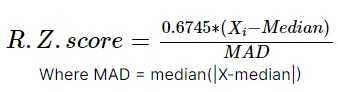

- 1.4826은 MAD를 정규분포의 표준편차와 같은 척도로 맞추기 위한 보정 상수

### 참고: Robust Z-score(Median/MAD 기반) 개념 정리

일반 z-score와 Robust z-score의 차이, 그리고 두 공식 표기가 동치임을 정리함.

**일반 Z-score의 한계**
- 일반 z-score는 평균(mean)과 표준편차(std)를 기준으로 계산하며, 평균과 표준편차 자체가 극단값(outlier)에 크게 영향을 받는 통계량임
- 본 프로젝트의 TransactionAmt, C컬럼군은 왜도가 매우 크고(예: TransactionAmt 왜도 14.4) 극단값이 다수 존재하는 분포로 확인되어, 일반 z-score 사용 시 평균과 표준편차 자체가 왜곡될 위험이 있음

**Robust Z-score 공식**
- Median(중앙값)과 MAD(Median Absolute Deviation, 중위절대편차)를 사용하여 극단값의 영향을 최소화함
- MAD = median(|x - median(x)|), 즉 각 값과 중앙값의 차이(절대값)를 구한 뒤 그 값들의 중앙값을 다시 취한 것

**공식 표기**
- R.Z.score = (x - median) / (1.4826 × MAD)
- R.Z.score = 0.6745 × (x - median) / MAD
- 두 표기는 수학적으로 동치임. 1.4826과 0.6745는 서로의 역수 관계이며, 표준정규분포에서 MAD의 이론적 값(약 0.6745)을 표준편차(σ=1)와 같은 척도로 보정하기 위한 상수임
- 분모에 1.4826을 곱하는 방식과 분자에 0.6745를 곱하는 방식은 계산 순서만 다를 뿐 결과는 동일함

**본 프로젝트에서의 활용**
- UID 기준 그룹별 거래금액에 대해 Robust z-score를 계산하여, 일반 z-score(평균/표준편차 기반) 대비 극단값에 더 안정적인 편차 지표로 활용함
- 일반 z-score와 Robust z-score의 Mann-Whitney U test 결과를 비교하여 어느 방식이 더 안정적인 신호를 제공하는지 검증함

In [ ]:
# def robust_zscore(series):
#     """median/MAD 기반 robust z-score 계산"""
#     median = series.median()
#     mad = (series - median).abs().median()
#     if mad == 0:
#         return pd.Series(np.nan, index=series.index)
#     return (series - median) / (1.4826 * mad)

# # UID 기준 그룹별로 robust z-score 계산
# df['amt_robust_zscore'] = df.groupby('UID', observed=True)['TransactionAmt'].transform(robust_zscore)

# # 그룹 내 거래가 1건뿐인 경우(MAD=0 또는 정의불가)는 NaN으로 남음 - 확인
# print(f"robust z-score 계산 불가 비율: {df['amt_robust_zscore'].isnull().mean():.1%}")
# print(f"\nrobust z-score 기초통계:\n{df['amt_robust_zscore'].describe()}")

robust z-score 계산 불가 비율: 6.2%

robust z-score 기초통계:
count    553847.000000
mean          0.612816
std         289.141954
min     -214942.546875
25%          -0.574286
50%           0.000000
75%           1.037157
max        3405.821777
Name: amt_robust_zscore, dtype: float64


In [19]:
print("MAD가 0은 아니지만 매우 작은 경우 확인:")
mad_by_uid = df.groupby('UID', observed=True)['TransactionAmt'].apply(
    lambda x: (x - x.median()).abs().median()
)
print(f"MAD가 0인 그룹: {(mad_by_uid == 0).sum()}개")
print(f"MAD가 0보다 크지만 0.01 미만인 그룹: {((mad_by_uid > 0) & (mad_by_uid < 0.01)).sum()}개")

print(f"\nrobust z-score 절댓값 상위 10개:")
print(df.nlargest(10, 'amt_robust_zscore', keep='all')[['UID', 'TransactionAmt', 'amt_robust_zscore']])
print(df.nsmallest(10, 'amt_robust_zscore', keep='all')[['UID', 'TransactionAmt', 'amt_robust_zscore']])

MAD가 0은 아니지만 매우 작은 경우 확인:
MAD가 0인 그룹: 21612개
MAD가 0보다 크지만 0.01 미만인 그룹: 2개

robust z-score 절댓값 상위 10개:
                      UID  TransactionAmt  amt_robust_zscore
422159   7970_490.0_325.0     1424.949951        3405.821777
104542  17480_181.0_220.0      200.000000        1902.093018
39343   10012_555.0_512.0       50.000000        1686.188354
277127  12839_321.0_251.0     2202.469971        1452.495605
515703  13899_555.0_299.0     1104.000000        1343.653076
87583      3376_488.0_nan       62.751999        1241.243408
23208    5567_583.0_123.0      100.000000        1106.181763
473910   9098_170.0_337.0     1364.949951        1016.630615
84404    9943_555.0_444.0      125.000000         890.341431
430966   9943_555.0_444.0      117.000000         782.421265
                      UID  TransactionAmt  amt_robust_zscore
94324   13815_514.0_337.0      100.000000     -214942.546875
153593  15592_494.0_343.0       49.000000       -4585.557617
96779   11518_479.0_436.0      100.000000   

### 해결: MAD에 최소 하한선(floor) 적용

- 분모가 너무 작아지는 걸 막기 위해, MAD의 최솟값을 일정 수준으로 강제. 
- 전체 데이터의 MAD를 기준으로 floor를 잡음.

In [20]:
def robust_zscore(series, mad_floor=None):
    """
    median/MAD 기반 robust z-score 계산.
    MAD가 0이거나 지나치게 작으면(분모 폭발 방지) NaN으로 처리한다.
    """
    median = series.median()
    mad = (series - median).abs().median()
    
    # MAD가 0이거나, 전체 데이터 기준 MAD의 일정 비율보다 작으면 계산 불가로 처리
    if mad_floor is not None and (mad == 0 or mad < mad_floor):
        return pd.Series(np.nan, index=series.index)
    if mad == 0:
        return pd.Series(np.nan, index=series.index)
    
    return (series - median) / (1.4826 * mad)

# 전체 데이터 기준 MAD를 계산해, 그 일정 비율(예: 5%)을 floor로 사용
global_median = df['TransactionAmt'].median()
global_mad = (df['TransactionAmt'] - global_median).abs().median()
mad_floor_value = global_mad * 0.05  # 전체 MAD의 5% 미만이면 신뢰 불가로 판단

print(f"전체 데이터 기준 MAD: {global_mad:.2f}")
print(f"적용할 MAD floor: {mad_floor_value:.4f}")

df['amt_robust_zscore'] = df.groupby('UID', observed=True)['TransactionAmt'].transform(
    lambda x: robust_zscore(x, mad_floor=mad_floor_value)
)

print(f"\nrobust z-score 계산 불가 비율: {df['amt_robust_zscore'].isnull().mean():.1%}")
print(f"\nrobust z-score 기초통계 (수정 후):\n{df['amt_robust_zscore'].describe()}")

전체 데이터 기준 MAD: 38.80
적용할 MAD floor: 1.9400

robust z-score 계산 불가 비율: 6.6%

robust z-score 기초통계 (수정 후):
count    551380.000000
mean          0.979422
std           4.914701
min        -186.172928
25%          -0.573317
50%           0.000000
75%           1.040298
max         523.118774
Name: amt_robust_zscore, dtype: float64


In [21]:
def test_mad_floor(df, floor_ratio):
    global_median = df['TransactionAmt'].median()
    global_mad = (df['TransactionAmt'] - global_median).abs().median()
    floor_value = global_mad * floor_ratio
    
    result = df.groupby('UID', observed=True)['TransactionAmt'].transform(
        lambda x: robust_zscore(x, mad_floor=floor_value)
    )
    return {
        'floor_ratio': floor_ratio,
        'floor_value': floor_value,
        'missing_pct': result.isnull().mean(),
        'std': result.std(),
        'min': result.min(),
        'max': result.max()
    }

floor_tests = [test_mad_floor(df, r) for r in [0.05, 0.1, 0.2, 0.3, 0.5]]
floor_test_df = pd.DataFrame(floor_tests)
print(floor_test_df.to_string(index=False))

 floor_ratio  floor_value  missing_pct      std         min        max
        0.05     1.940000     0.066312 4.914701 -186.172928 523.118774
        0.10     3.880000     0.071919 4.729365  -84.311348 523.118774
        0.20     7.759999     0.094480 4.221760  -66.739189 523.118774
        0.30    11.639999     0.128296 3.880866  -66.739189 523.118774
        0.50    19.399998     0.265018 3.917992  -66.739189 523.118774


**floor를 계속 올려도 max값(523.12)이 전혀 안 줄어듬 -> 다른 원인이 있다는 신호**

In [22]:
# floor_ratio=0.3 기준으로 재계산 (결측 13%, std 3.88로 균형 적절해 보임)
global_median = df['TransactionAmt'].median()
global_mad = (df['TransactionAmt'] - global_median).abs().median()
mad_floor_value = global_mad * 0.3

df['amt_robust_zscore'] = df.groupby('UID', observed=True)['TransactionAmt'].transform(
    lambda x: robust_zscore(x, mad_floor=mad_floor_value)
)

# max값을 만드는 거래 직접 확인
max_row = df.loc[df['amt_robust_zscore'].idxmax()]
print("최댓값을 만드는 거래:")
print(max_row[['UID', 'TransactionAmt', 'amt_robust_zscore', 'isFraud']])

# 그 UID의 전체 거래 내역 확인
target_uid = max_row['UID']
print(f"\nUID '{target_uid}'의 전체 거래 내역:")
print(df.loc[df['UID'] == target_uid, ['TransactionAmt', 'isFraud']].sort_values('TransactionAmt'))

최댓값을 만드는 거래:
UID                  16075_514.0_205.0
TransactionAmt            31937.390625
amt_robust_zscore           523.118774
isFraud                              0
Name: 274336, dtype: object

UID '16075_514.0_205.0'의 전체 거래 내역:
        TransactionAmt  isFraud
110263       40.000000        0
551764       43.950001        0
255367       45.950001        0
22022        49.950001        0
109896       50.000000        0
72516        53.950001        0
177669       53.950001        0
108720       53.950001        0
45310        53.950001        0
201526       58.950001        0
218331       58.950001        0
232664       58.950001        0
394261       58.950001        0
232712       63.950001        0
133207       73.949997        0
46140        75.000000        0
76188        75.000000        0
563191       83.949997        0
156286       88.949997        0
97256       100.000000        0
574809      100.000000        0
84432       100.000000        0
91146       100.000000        0

### Robust Z-score 검증 결과 요약

- floor_ratio를 0.05~0.5로 조정한 결과, min값은 floor 강화에 따라 점진적으로 안정화되었으나(-214942 → -66.7) max값(523.12)은 floor와 무관하게 고정되어 있어 별도 원인을 점검함
- max값을 생성하는 거래를 직접 확인한 결과, 해당 UID(40여 건의 거래가 대부분 40~450 사이에 분포)에서 전체 데이터 최댓값(31,937.39)과 일치하는 거래 2건이 발견됨
- 이는 계산 오류가 아니라, 해당 사용자의 평소 패턴 대비 실제로 극단적인 이상 거래를 robust z-score가 정확히 탐지한 결과로 확인됨
- 해당 거래는 isFraud=0(정상)으로 분류되어 있어, Day 2에서 확인한 "거래금액 최댓값은 오히려 정상 거래에서 발생한다"는 패턴과 일치함
- floor_ratio=0.3(MAD floor=11.64) 적용 시 결측 비율 12.8%, std 3.88로 안정적인 수준을 보여 최종 기준으로 채택함
- 동일 UID 내에 큰 금액 편차(40~450 vs 31,937)가 공존하는 사례는, UID(card1+card2+addr1)가 완벽한 개인 식별자가 아니라는 기존 한계(2.4절, Day 3 UID 검증)와도 일관되는 것으로 판단됨

### 6. 일반 z-score vs Robust z-score 비교 검정

두 방식의 Mann-Whitney U test 결과를 비교하여, robust 버전이 실제로 더 강한(또는 더 안정적인) 신호를 보이는지 확인합니다.

In [23]:
result_normal_z = mannwhitney_test(df, 'amt_zscore')
result_robust_z = mannwhitney_test(df, 'amt_robust_zscore')

comparison = pd.DataFrame([result_normal_z, result_robust_z])
print(comparison.to_string(index=False))

         variable  median_normal  median_fraud       u_stat       p_value  effect_size_r  significant
       amt_zscore      -0.288183     -0.162362 4890511186.0 4.513382e-125       0.099296         True
amt_robust_zscore       0.000000      0.253604 3976826667.0 9.668823e-155       0.115732         True


### 일반 Z-score vs Robust Z-score 최종 비교 결과 요약

- floor_ratio=0.3 적용 후 amt_robust_zscore의 effect size가 0.108 → 0.116으로 추가 개선됨. floor 적용으로 계산 오류성 극단값(분모 폭발)이 제거되면서 노이즈가 줄어들고 진짜 신호가 더 명확하게 드러난 것으로 판단됨
- 최종 비교: amt_zscore(effect size=0.099) < amt_robust_zscore(effect size=0.116) → robust 방식이 일반 방식보다 일관되게 더 강한 신호를 보임
- 정상 거래 중앙값(amt_robust_zscore=0.0)과 사기 거래 중앙값(0.254)의 차이가 일반 z-score보다 더 뚜렷하게 나타남
- 4.3절 최종 변수 세트에는 amt_robust_zscore를 amt_zscore보다 우선하여 채택하며, 두 변수 간 상관관계가 매우 높을 것으로 예상되어 다중공선성 방지를 위해 모델 입력 시 하나만 선택하거나 PCA 등으로 통합하는 것을 고려함

### 참고: Day 1 이상치 보존 결정과의 연결

Day 1에서 TransactionAmt 분석 시 "극단값을 제거하지 않고 로그변환 및 사용자별 금액 편차로 다룬다"고 결정했던 사항이, 오늘 Robust z-score 검증을 통해 실제로 의미 있는 결정이었음이 확인됨.

- Day 1에서 확인한 전체 데이터 최댓값(31,937.39)이, 오늘 Robust z-score 최댓값(523.12)을 생성한 거래와 동일한 금액으로 확인됨
- 만약 Day 1에서 이 거래를 이상치로 판단하여 제거했다면, "특정 사용자의 평소 패턴에서 극단적으로 벗어난 거래"라는 신호 자체가 분석에서 사라졌을 것임
- 제거하지 않고 보존한 결과, 동일한 거래가 전체 기준 절대값(31,937)이 아니라 사용자(UID) 기준 상대적 편차(평소 40~450 대비 500배 이상 벗어남)로 재해석되어 더 유의미한 형태의 정보로 전환됨
- 다만 해당 거래는 isFraud=0(정상)으로 확인되어, 금액 편차가 크다는 사실 자체가 사기의 충분조건은 아님을 보여줌. 따라서 amt_robust_zscore는 단독 판단 기준이 아니라 다른 변수와 결합하여 모델이 종합적으로 학습할 보조 신호로 활용함
- 이 사례는 "이상치 제거"와 "이상치를 변환하여 활용"이 서로 다른 결과를 낳을 수 있음을 보여주는 근거로, 보고서/블로그에 데이터 처리 의사결정의 타당성을 설명하는 사례로 활용 가능함

### 7. 시간대 기준 Z-score

UID 기준 편차 외에, 거래 시간대(hour) 기준으로도 금액 편차를 계산합니다. 같은 시간대(예: 새벽 시간)에 발생한 거래들 사이에서 이번 거래가 얼마나 벗어나는지를 측정하며, 이는 "행동 패턴 단위" 신호로 UID 기반 신호를 보완합니다.

이 작업을 위해 먼저 TransactionDT로부터 시간 파생변수(hour)를 생성합니다 (4.3절 작업 항목과 연계).

In [24]:
# 시간 파생변수 생성 (TransactionDT는 초 단위 경과시간)
df['Transaction_hour'] = (df['TransactionDT'] / 3600) % 24
df['Transaction_hour'] = df['Transaction_hour'].astype(int)

print("시간대별 거래 분포:")
print(df['Transaction_hour'].value_counts().sort_index())

# 시간대 기준 robust z-score
df['amt_hour_robust_zscore'] = df.groupby('Transaction_hour', observed=True)['TransactionAmt'].transform(
    lambda x: robust_zscore(x, mad_floor=mad_floor_value)
)

print(f"\n시간대 기준 robust z-score 계산 불가 비율: {df['amt_hour_robust_zscore'].isnull().mean():.1%}")
print(f"\n기초통계:\n{df['amt_hour_robust_zscore'].describe()}")

result_hour_z = mannwhitney_test(df, 'amt_hour_robust_zscore')
print(f"\n[Mann-Whitney 검정]\n{result_hour_z}")

시간대별 거래 분포:
Transaction_hour
0     37795
1     32797
2     26732
3     20802
4     14839
5      9701
6      6007
7      3704
8      2591
9      2479
10     3627
11     6827
12    12451
13    20315
14    28328
15    33859
16    38698
17    40723
18    41639
19    42115
20    41782
21    41641
22    41139
23    39949
Name: count, dtype: int64

시간대 기준 robust z-score 계산 불가 비율: 0.0%

기초통계:
count    590540.000000
mean          1.156606
std           4.259774
min          -1.425782
25%          -0.489849
50%           0.000000
75%           1.112317
max         613.400574
Name: amt_hour_robust_zscore, dtype: float64

[Mann-Whitney 검정]
{'variable': 'amt_hour_robust_zscore', 'median_normal': np.float32(0.0), 'median_fraud': np.float32(0.06498138), 'u_stat': np.float64(5857190951.0), 'p_value': np.float64(0.20525111099131943), 'effect_size_r': np.float64(0.005179162694889716), 'significant': np.False_}


### 참고: Transaction_hour 변수의 해석상 한계

TransactionDT 기반으로 생성한 Transaction_hour가 실제 현지 시각과 일치하는지 검증할 수 없다는 한계를 정리함.

**한계의 원인**
- TransactionDT는 Kaggle 공식 설명상 "임의의 기준 시점으로부터의 경과초(timedelta)"로만 명시되어 있으며, 그 기준 시점이 실제로 몇 시 몇 분에 해당하는지는 공개되어 있지 않음
- 따라서 `(TransactionDT / 3600) % 24`로 계산한 Transaction_hour 값이 실제 자정, 새벽, 오후 등 어느 시각에 대응하는지 확인할 방법이 없음

**안전하게 사용할 수 있는 범위**
- 24시간 주기로 거래량이 일관되게 변동하는 패턴이 존재한다는 사실 자체(특정 구간에서 최저/최고를 보임)
- Transaction_hour를 모델 입력 변수로 사용하는 것(모델은 값 자체로 학습하므로 실제 시각 의미와 무관하게 작동함)
- 통계검정에서 "이 위상(phase) 구간과 사기 여부가 연관 있는가"를 확인하는 것

**위험한 사용 방식 (지양)**
- "심야 시간대에 사기가 많다", "이른 아침 거래가 적은 것은 사람들이 자고 있어서다"와 같이 특정 시각대에 실생활 의미를 부여하는 해석
- 보고서·블로그에서 Transaction_hour 값을 실제 시각으로 단정하여 서술하는 것

**적용 원칙**
- 이후 Transaction_hour를 활용한 분석 결과는 "기준점으로부터 특정 위상 구간에 거래/사기가 몰린다"는 식으로 서술하며, 그 위상이 실제 새벽/낮/심야 중 어디에 해당하는지는 검증 불가능한 추정임을 명시함

### 시간대 기준 Z-score 검증 결과 요약

- 시간대별 거래 분포는 특정 구간(약 5~11시 위상)에서 최저(9시 위상에서 2,479건으로 최저점), 다른 구간(약 17~22시 위상)에서 최고(19시 위상에서 42,115건)를 보이는 뚜렷한 24시간 주기 패턴이 확인됨. 다만 이 위상이 실제 어느 시각대에 대응하는지는 검증할 수 없음(위 참고 항목 참조)
- amt_hour_robust_zscore는 통계적으로 유의하지 않음(p=0.205, effect size=0.005)으로 확인되어, 시간대 기준 편차는 사기탐지 신호로서 가치가 없는 것으로 판단됨
- 원인으로는 "시간대"라는 그룹 단위가 지나치게 크고(시간당 수천~수만 건) 그룹 내 개인별 소비 패턴 분산이 매우 커서, 개별 거래의 일탈이 그룹 분산에 묻히는 것으로 추정됨
- UID 기준 편차(amt_robust_zscore, effect size=0.116)와 비교했을 때, "개인에 가까운 단위"로 그룹화할 때만 편차 변수가 유의미한 신호를 갖는다는 점이 확인됨
- 결론: amt_hour_robust_zscore는 4.3절 최종 변수 세트에서 제외하며, 행동 패턴 단위 feature는 그룹 단위가 충분히 좁아야 효과가 있다는 시사점을 확인함

### 8. 그룹 결측 플래그 일괄 생성

Day 2에서 검증한 V컬럼 15개 그룹(12개 그룹이 통계적으로 유의)을 기준으로, 각 그룹의 대표 결측 플래그를 정식 변수로 생성합니다. 통계적으로 무의미했던 V_group1, 2, 3은 결측 플래그 생성에서 제외합니다.

In [27]:
# 잘못 생성된 V_group*_missing 컬럼 제거
wrong_flags = [c for c in df.columns if re.match(r'^V_group\d+_missing$', c)]
df = df.drop(columns=wrong_flags)
print(f"제거된 컬럼: {wrong_flags}")

# V컬럼을 'V+숫자' 패턴으로만 명확히 한정 (재실행해도 안전하도록)
v_cols = [c for c in df.columns if re.fullmatch(r'V\d+', c)]
print(f"\n정확한 V컬럼 개수: {len(v_cols)}")  # 339가 나와야 정상

제거된 컬럼: ['V_group1_missing', 'V_group4_missing', 'V_group5_missing', 'V_group6_missing', 'V_group7_missing', 'V_group8_missing', 'V_group9_missing', 'V_group10_missing', 'V_group12_missing', 'V_group15_missing', 'V_group16_missing']

정확한 V컬럼 개수: 339


In [30]:
import re

# V컬럼을 'V+숫자' 패턴으로만 명확히 한정 (재실행 시에도 항상 339개로 고정됨)
v_cols = [c for c in df.columns if re.fullmatch(r'V\d+', c)]
v_missing_pct = (df[v_cols].isnull().sum() / len(df) * 100).round(4)

v_group_df = v_missing_pct.reset_index()
v_group_df.columns = ['column', 'missing_pct']
v_groups = v_group_df.groupby('missing_pct')['column'].apply(list).reset_index()
v_groups['n_cols'] = v_groups['column'].apply(len)
# n_cols 내림차순, 동률 시 missing_pct 오름차순으로 순서 고정 (재현성 확보)
v_groups = v_groups.sort_values(['n_cols', 'missing_pct'], ascending=[False, True]).reset_index(drop=True)

print(f"V컬럼 {len(v_cols)}개가 {len(v_groups)}개 그룹으로 분류됨")

v_flag_summary = []
for i, row in v_groups.iterrows():
    representative_col = row['column'][0]
    flag_name = f'V_group{i+1}_missing'
    df[flag_name] = df[representative_col].isnull().astype(np.int8)
    
    result = chi_square_test(df, flag_name)
    result['n_cols_in_group'] = row['n_cols']
    result['flag_name'] = flag_name
    v_flag_summary.append(result)

v_flag_summary_df = pd.DataFrame(v_flag_summary)

SIGNIFICANT_THRESHOLD = 0.02
adopted_flags = v_flag_summary_df[
    (v_flag_summary_df['significant']) & (v_flag_summary_df['cramers_v'] >= SIGNIFICANT_THRESHOLD)
]
dropped_flags = v_flag_summary_df[
    ~((v_flag_summary_df['significant']) & (v_flag_summary_df['cramers_v'] >= SIGNIFICANT_THRESHOLD))
]

print(f"\n채택할 V그룹 결측 플래그: {len(adopted_flags)}개")
print(adopted_flags[['flag_name', 'n_cols_in_group', 'cramers_v']].to_string(index=False))

print(f"\n제외할 V그룹 결측 플래그: {len(dropped_flags)}개")
print(dropped_flags[['flag_name', 'n_cols_in_group', 'cramers_v']].to_string(index=False))

df = df.drop(columns=dropped_flags['flag_name'].tolist())

V컬럼 339개가 15개 그룹으로 분류됨

채택할 V그룹 결측 플래그: 11개
        flag_name  n_cols_in_group  cramers_v
 V_group1_missing               46   0.125019
 V_group4_missing               31   0.133444
 V_group5_missing               23   0.033690
 V_group6_missing               22   0.049533
 V_group7_missing               20   0.029745
 V_group8_missing               19   0.133912
V_group10_missing               18   0.021389
V_group11_missing               18   0.020852
V_group12_missing               16   0.130283
V_group14_missing               11   0.088307
V_group15_missing               11   0.020873

제외할 V그룹 결측 플래그: 4개
        flag_name  n_cols_in_group  cramers_v
 V_group2_missing               43   0.002204
 V_group3_missing               32   0.002208
 V_group9_missing               18   0.003737
V_group13_missing               11   0.000218


### 참고: V그룹 번호 고정 (재현성 확보)

V_group 번호가 실행마다 달라질 수 있는 문제와 해결 방법을 정리함.

**문제 원인**
- 그룹 정렬 기준이 n_cols(그룹 크기) 내림차순이었으나, 그룹 크기가 동일한 경우(예: 18개 컬럼 그룹이 2개, 11개 컬럼 그룹이 2개)가 존재함
- 동률 항목의 순서는 정렬 전 원래 순서에 의존하며, 이는 실행 환경이나 그룹화 과정의 미세한 차이에 따라 달라질 수 있음
- 실제로 Day 2와 Day 3 실행에서 V_group10과 V_group11(둘 다 18개 컬럼)의 번호가 서로 바뀌어 나타남을 확인함

**해결**
- 정렬 기준에 missing_pct(결측률 값)를 보조 기준으로 추가하여 동률을 깨고 순서를 고정함: `sort_values(['n_cols', 'missing_pct'], ascending=[False, True])`
- 이후 몇 번을 재실행해도 동일한 그룹이 항상 동일한 번호를 받도록 보장함

**유의점**
- 그룹 번호 자체는 임의의 라벨이며, Cramér's V 등 통계값은 그룹 구성과 무관하게 항상 동일함(Day 2-Day 3 비교에서 확인)
- 다만 보고서·블로그에 그룹 번호를 인용하여 서술할 경우, 노트북 재실행 시에도 동일한 그룹을 가리키도록 정렬 기준을 고정하는 것이 분석 재현성 확보에 필요함

### Day 3 중간 저장

세션 종료에 대비하여 현재까지의 작업 결과를 저장합니다. 다음 세션에서는 V컬럼 차원축소(그룹별 대표변수 또는 PCA)부터 이어갑니다.

In [31]:
import os
df.to_parquet("../data/processed/day3_merged.parquet", index=False)
print("저장 완료, 파일 크기(MB):", os.path.getsize("../data/processed/day3_merged.parquet") / 1024**2)

저장 완료, 파일 크기(MB): 99.13948440551758
